In [ ]:
#pip install torch

In [ ]:
import torch as th
import numpy as np
import random

#сделаем инициализацию random seed,
#чтобы наши эксперименты были воспроизводимы

random.seed(0)
np.random.seed(0)
th.manual_seed(0)
th.cuda.manual_seed(0)
th.backends.cudnn.deterministic=True

In [ ]:
#скачивание датасета для классификации изображений
import torchvision.datasets

MNIST_train = torchvision.datasets.MNIST('./', download = True, train = True)
MNIST_test = torchvision.datasets.MNIST('./', download = True, train = False)

100%|██████████| 9912422/9912422 [00:00<00:00, 119652319.89it/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 62152741.83it/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 74003952.75it/s]

Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw


100%|██████████| 4542/4542 [00:00<00:00, 678727.69it/s]


Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



In [ ]:
X_train = MNIST_train.train_data
y_train = MNIST_train.train_labels
X_test = MNIST_test.test_data
y_test = MNIST_test.test_labels

/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:65: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:80: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:70: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


In [ ]:
#посмотрим какой у данных тип
X_train.dtype, y_train.dtype

(torch.uint8, torch.int64)

In [ ]:
#данные имеют тип беззнаковый 8, а таргеты - целые 64 бита
#преобразуем сразу данные в веществиенный тип
X_train = X_train.float()
X_test = X_test.float()

In [ ]:
#посмотрим на расзмерность датасетов
X_train.shape, X_test.shape
#это очень маленькие картинки, именно поэтому мы можем использовать
#полносвязную нейронную сеть для такой задачи, а не сверточные сети

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

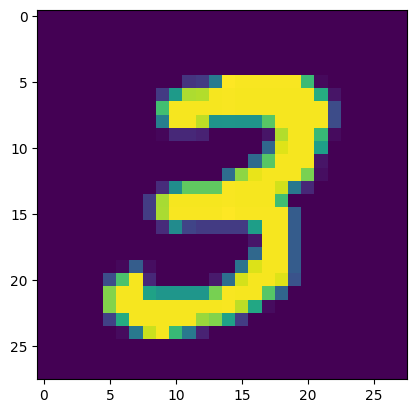

tensor(3)


In [ ]:
#посмотрим на картинки
import matplotlib.pyplot as plt
plt.imshow(X_train[7, :, :])
plt.show()
print(y_train[7])

In [ ]:
#у нас трезмерный тензор, мы хотим двумерный тензор,
#чтобы первая рамерность сохранилась, то есть 60000 картинок
#вместо 28 и 28 будет 764 пикселя

X_train = X_train.reshape([-1, 28*28])
X_test = X_test.reshape([-1, 28*28])

print(X_train)


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [ ]:
#Создание сети
# на выходе у нас числа от 0 до 9
class MNISTnet(th.nn.Module):
  def __init__(self):
    super (MNISTnet, self).__init__()
    self.fc1 = th.nn.Linear(28*28, 500)
    self.act1 = th.nn.Tanh()
    self.fc2 = th.nn.Linear(500, 500)
    self.act2 = th.nn.Tanh()
    self.fc3 = th.nn.Linear(500, 10)
    self.sm = th.nn.Softmax(dim=1)

  def forward(self, x):
    x = self.fc1(x)
    x = self.act1(x)
    x = self.fc2(x)
    x = self.act2(x)
    x = self.fc3(x)
    return x


  def predict(self,x):
    with th.no_grad():
        x = self.forward(x)
        x = x.reshape(1, 10)
        x = self.sm(x)
        _, predicted = th.max(x, 1)
    return predicted.item()

net = MNISTnet()

In [ ]:
''' есть ли видеокарта?'''
th.cuda.is_available()

False

In [ ]:
'''смотрим, занята ли карта какими либо вычислениями'''
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
""" теперь нужно переложить вычисления на видеокарту"""

device = th.device('cuda:0' if th.cuda.is_available() else 'cpu')
net = net.to(device)

In [ ]:
#лосс функция
loss = th.nn.CrossEntropyLoss()

#оптимизатор
opt = th.optim.Adam(net.parameters(), lr = 0.001)


In [ ]:
def learn(opt):
    batch_size = 50   # размер батча
    epochs = 40   #количество эпох

    train_losses = []
    test_losses = []

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    '''данные тренировочной выборки будем перекладывать на cuda по батчам'''
    for epoch in range(epochs):
        order = np.random.permutation(len(X_train))
        for start_index in range (0,len(X_train), batch_size):
            opt.zero_grad()
            batch_index = order[start_index:start_index+batch_size]

            X_batch = X_train[batch_index]
            y_batch = y_train[batch_index]

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = net.forward(X_batch)
            loss_val = loss(preds, y_batch)
            loss_val.backward()

            opt.step()

        train_losses.append(loss_val.item())
        test_preds = net.forward(X_test)
        test_loss = loss(test_preds, y_test).item()
        test_losses.append(test_loss)

        if epoch % 10 == 0:
            test_preds = test_preds.argmax(dim=1)
            print((test_preds == y_test).float().mean())

tensor(0.9010)
tensor(0.9325)
tensor(0.9327)
tensor(0.9461)


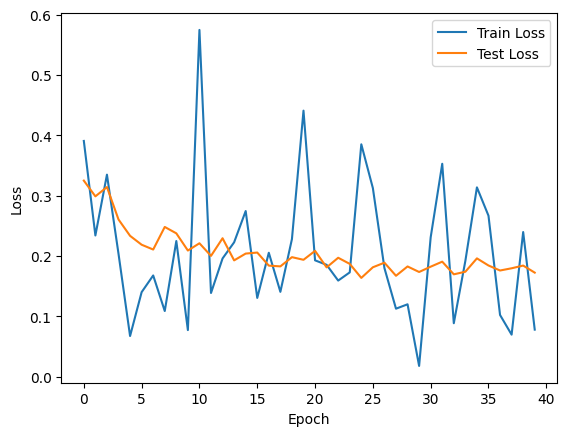

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

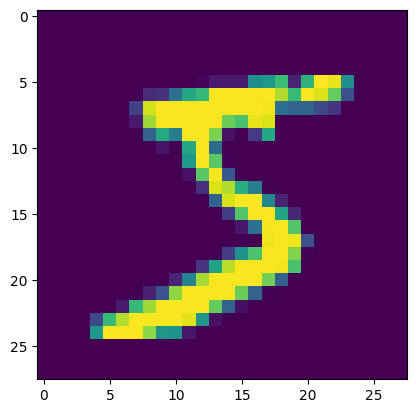

tensor(5)


In [ ]:
X_train = X_train.reshape([-1, 28, 28])
plt.imshow(X_train[0, :])
plt.show()
print(y_train[0])

In [ ]:
X_train = X_train.reshape([-1, 28*28])
X_train = X_train.to(device)
print(net.predict(X_train[0, :]))

5


###Задание


1.   Дописать код после фразы Ваш_Код_Здесь.
2.   Поэкспериментировать с гиперпараметрами нейронной сети, чтобы добиться более высокой точности классификации.
4.   Построить на одном графике loss для тестовой выборки и для обучающей.
5.   Ведет ли увеличение количества эпох (40 эпох -> 200 эпох) к улучшению метрик на валидации?
7.   Показать результат работы модели с использованием функции predict (необходимо написать функцию predict).
